Mounted at /content/drive
Tìm thấy 8 nhóm trạm sau khi gộp.


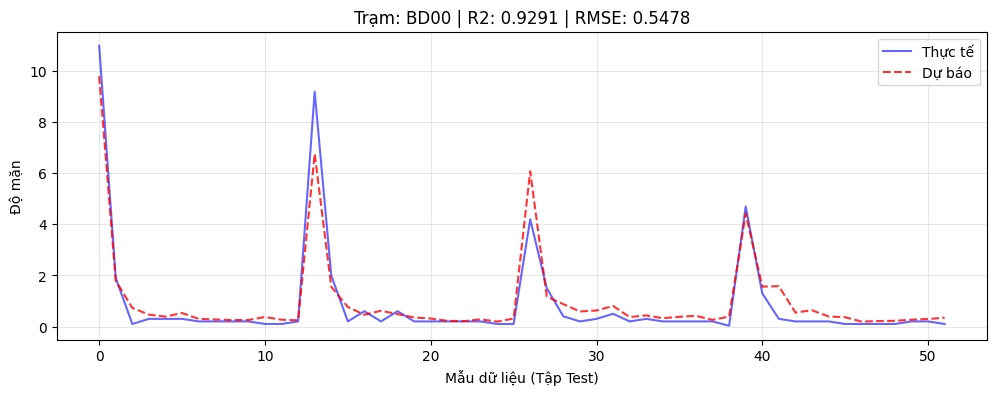

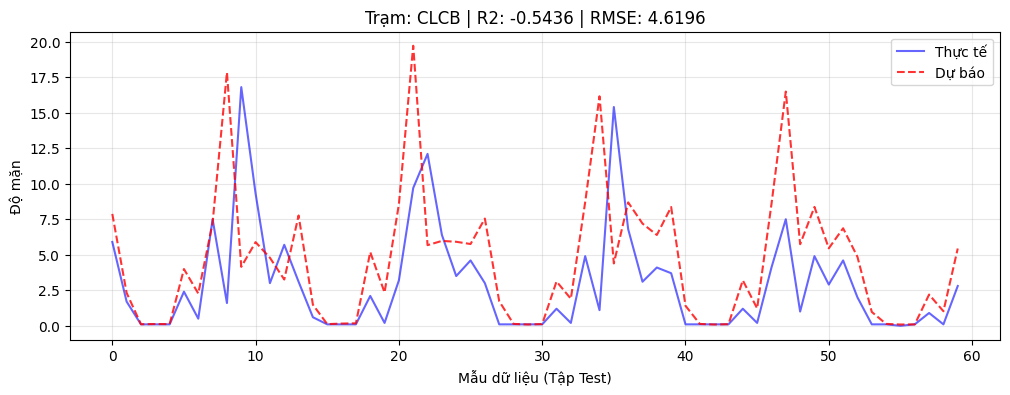

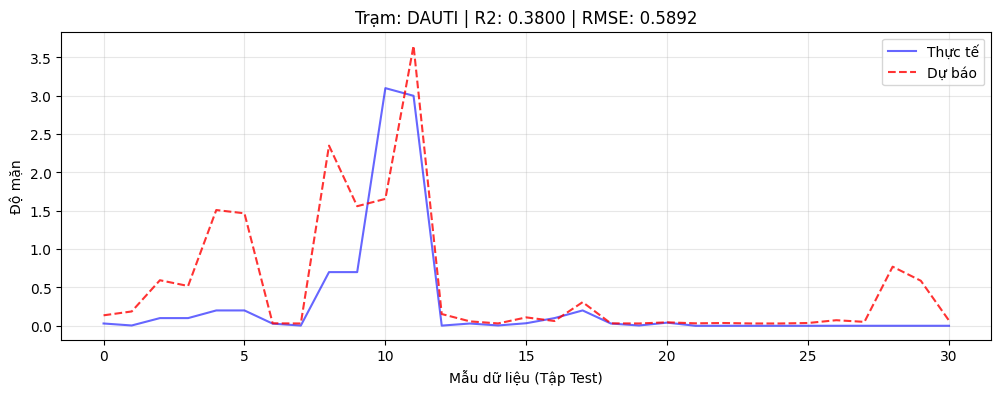

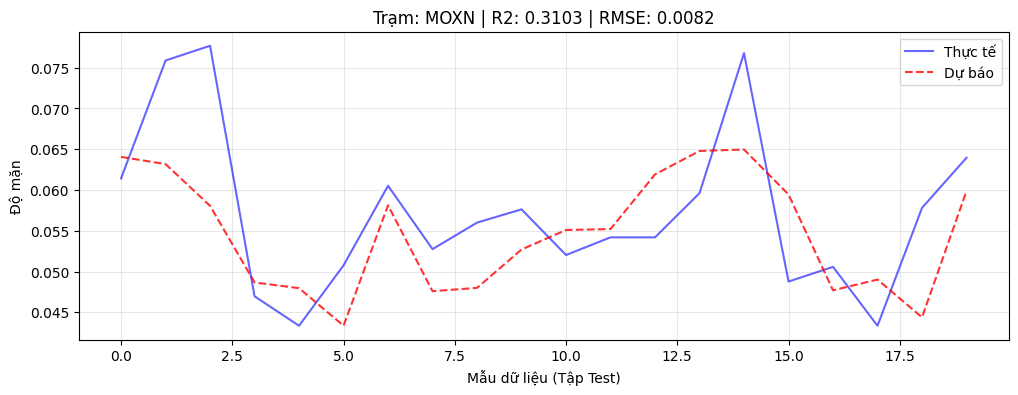

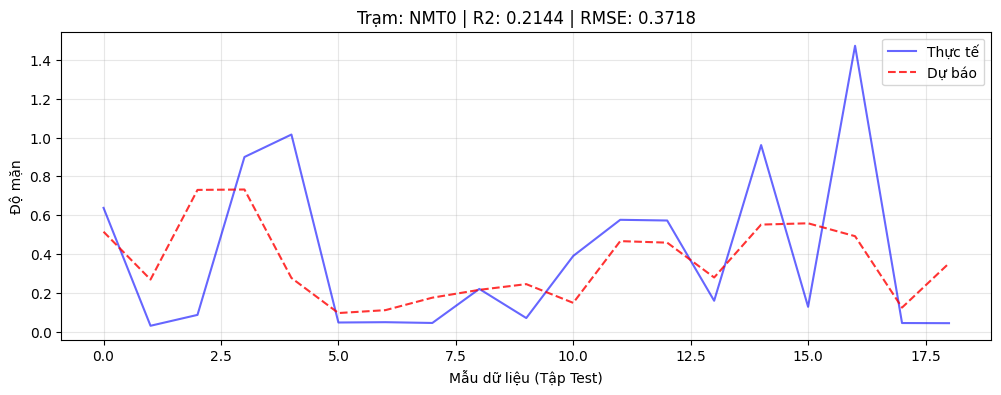

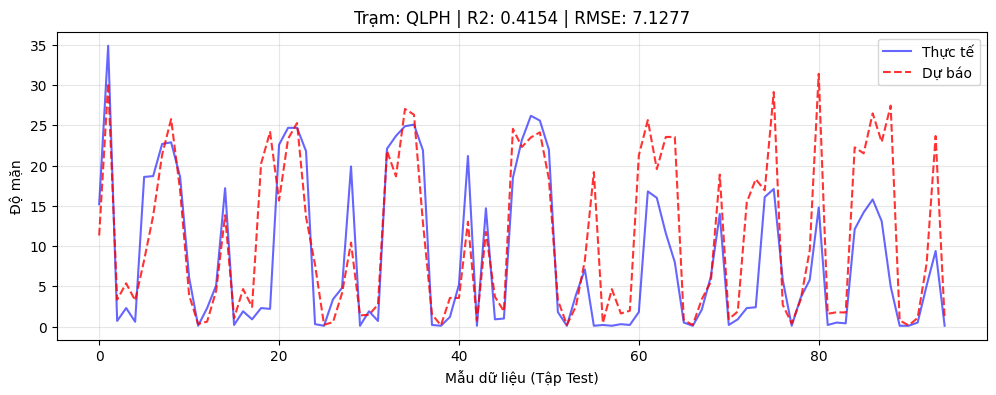

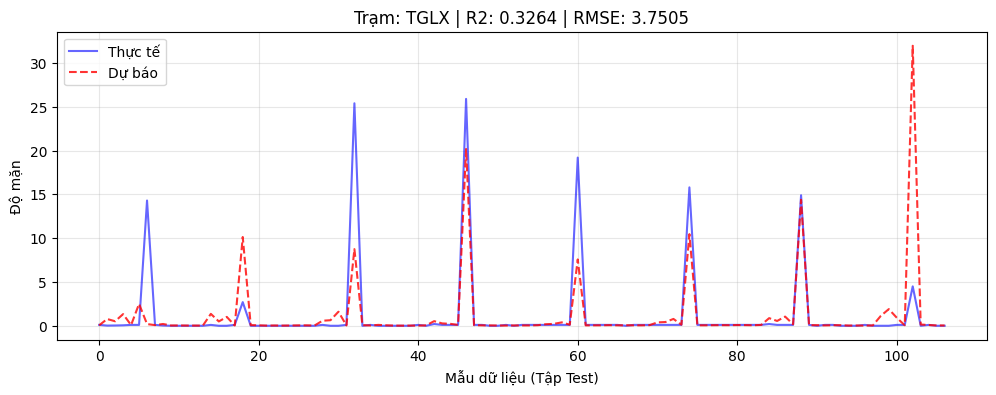

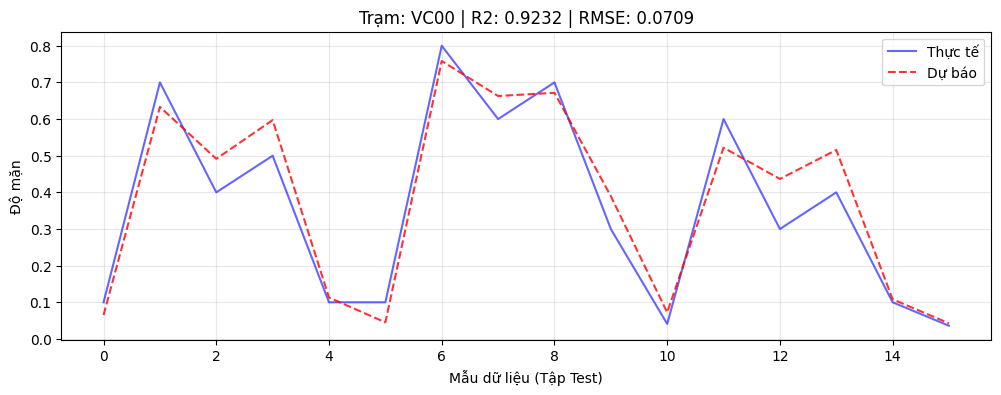

In [1]:
import pandas as pd
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Kết nối với Drive
from google.colab import drive
drive.mount('/content/drive')

# Đọc dữ liệu
path = '/content/drive/MyDrive/Final__Data_Salinity.csv'
df = pd.read_csv(path)

# Tiền xử lý dữ liệu
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])

# GỘP MÃ TRẠM
df['Matram'] = df['Matram'].astype(str).str[:-6]
df = df.sort_values(['Matram', 'Date'])

# TẠO LAG FEATURES
df['Salinity_Lag1'] = df.groupby('Matram')['Salinity'].shift(1)
df['Salinity_Lag2'] = df.groupby('Matram')['Salinity'].shift(2)

# Lọc tháng 2-5
df = df.dropna(subset=['Salinity_Lag1', 'Salinity_Lag2']).copy()
df = df[(df['Date'].dt.month >= 2) & (df['Date'].dt.month <= 5)].copy()

col_dist = 'Dist_to_TanChau_km'
features = [
    'longitude', 'latitude', 'Z.Elev', col_dist,
    'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos',
    'WL_Mean_3D_Lag', 'WL_Mean_7D_Lag',
    'Salinity_Lag1', 'Salinity_Lag2'
]
target = 'Salinity'

# VẼ BIỂU ĐỒ CHO TẤT CẢ CÁC NHÓM TRẠM
all_stations = df['Matram'].unique()
print(f"Tìm thấy {len(all_stations)} nhóm trạm sau khi gộp.")

for station in all_stations:
    station_df = df[df['Matram'] == station].reset_index(drop=True)

    # Chỉ train nếu trạm có đủ dữ liệu
    if len(station_df) < 40:
        print(f"Trạm {station} quá ít dữ liệu ({len(station_df)} dòng), bỏ qua.")
        continue

    # Chia train/test (80/20) theo thời gian cho từng trạm
    split_idx = int(len(station_df) * 0.8)
    train_df = station_df.iloc[:split_idx]
    test_df = station_df.iloc[split_idx:]

    X_train, y_train = train_df[features], train_df[target]
    X_test, y_test = test_df[features], test_df[target]

    # Khởi tạo và huấn luyện
    model = xgb.XGBRegressor(
        objective='reg:tweedie',
        tweedie_variance_power=1.2,
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        early_stopping_rounds=50,
        random_state=42
    )

    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    # Dự báo
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Vẽ biểu đồ
    plt.figure(figsize=(12, 4))
    plt.plot(y_test.values, label='Thực tế', color='blue', alpha=0.6)
    plt.plot(y_pred, label='Dự báo', color='red', linestyle='--', alpha=0.8)
    plt.title(f'Trạm: {station} | R2: {r2:.4f} | RMSE: {rmse:.4f}')
    plt.xlabel('Mẫu dữ liệu (Tập Test)')
    plt.ylabel('Độ mặn')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()